# Evaluation of RAG System

This notebook evaluates retrieval-augmented generation performance using RAGAS metrics and visualizations to assess answer quality, context relevance, and faithfulness.


### Import libraries

In [ ]:
from langchain_community.chat_models import ChatOllama
from langchain_community.embeddings import HuggingFaceEmbeddings
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)

from datasets import Dataset
import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))
import config

/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/2469971125.py:4: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/2469971125.py:4: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/2469971125.py:4: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/

### Helper Variables & Functions

In [4]:
ragas_llm = ChatOllama(model=config.MODEL_NAME)
ragas_embeddings = HuggingFaceEmbeddings(model_name=config.EMBEDDING_MODEL_ID)

/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/1678170326.py:1: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  ragas_llm = ChatOllama(model=config.MODEL_NAME)
/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/1678170326.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  ragas_embeddings = HuggingFaceEmbeddings(model_name=config.EMBEDDING_MODEL_ID)
Loading weights: 100%|

In [27]:

data_samples = {
    'user_input': [
        "What are the first steps to take if one or more channels on the MDX-4200 show an elevated baseline signal (> 500 counts at dark)?",
        "What is the corrective action if the MDX-4200 filter wheel does not home or skips positions?",
        "What is the procedure for an ADC output showing a non-linear response curve (FC-ELC-01)?",
        "What must be verified if a module fails an EMC pre-compliance test (FC-ELC-03)?",
        "When an issue with the MDX-4200 cannot be resolved by following the symptom-cause-action table, how should a technician escalate to Level 2 support?",
        "A field service engineer reports measured absorbance values are consistently 25% lower than expected. Which optical components should be cleaned or replaced, and what is the specific threshold for LED replacement?",
        "We are seeing an elevated baseline signal of over 600 counts on five different channels. Does the troubleshooting guide recommend a photodiode array replacement in this specific scenario?",
        "If only a single channel shows an elevated baseline signal at dark, does the troubleshooting guide immediately require a part replacement, or is there a repair step?",
        "What specific decoupling capacitors should be inspected on the signal PCB if the ADC readings are noisy or drifting due to power supply ripple exceeding 10 mVpp?",
        "A module failed EMC pre-compliance at the customer site. What is the required torque for the shielding enclosure (PN-SP-5503) screws to ensure proper integrity?",
        "What hardware tools and software versions are required for a technician to access the diagnostic interface of the MDX-4200 series?",
        "Which command should be executed to verify if an ADC IC is defective when a non-linear response curve is observed, and what is the pass/fail deviation limit?",
        "What is the required corrective action if the relative LED power is measured at 80% of its factory value during a CMD_LED_ITEST diagnostic run?",
        "Recent testing of batch PO-2026-0312 showed elevated crosstalk. Based on incident report IR-2026-017, what was the physical root cause of this alignment drift during the 18-hour production run?",
    ],
    'retrieved_contexts': [
        ["Run dark-current test via CMD_DARK_TEST. If > 3 channels affected, replace photodiode array PN-OS-4201. Single-channel failures may indicate a solder joint defect — re-flow affected pads."],
        ["Power-cycle the module. Run CMD_FWHEEL_HOME. If error persists, check motor connector (J4) seating. Inspect filter wheel PN-OS-4204 for debris. If encoder index pulse is missing, escalate to Level 2 (RMA required)."],
        ["Run CMD_ADC_LINTEST with calibration source. If deviation > ±3 LSB, replace ADC PN-SP-5501. Requires re-calibration per PROC-CAL-401."],
        ["Verify all shield screws are torqued to 0.15 ± 0.02 Nm. Check gasket condition on EMI enclosure PN-SP-5503. If shield was opened for service, ensure conductive gasket (MTS-GSKT-EMI-01) is properly seated. Re-test per EN 61326-1."],
        ["Level 2 (Engineering Support): Contact eng-support@medtech-solutions.de with diagnostic log file (.mtslog) and photos."],
        ["Run CMD_LED_ITEST to measure relative LED power. If < 85% of factory value, replace LED PN-OS-4203. Also clean collimating lens PN-OS-4202 with IPA and lint-free wipe. Re-calibrate per PROC-CAL-401."],
        ["Run dark-current test via CMD_DARK_TEST. If > 3 channels affected, replace photodiode array PN-OS-4201."],
        ["Single-channel failures may indicate a solder joint defect — re-flow affected pads."],
        ["Measure 3.3 V rail ripple with oscilloscope (BW ≥ 200 MHz). If > 10 mVpp, check decoupling capacitors C12, C15, C18 on the signal PCB."],
        ["Verify all shield screws are torqued to 0.15 ± 0.02 Nm. Check gasket condition on EMI enclosure PN-SP-5503."],
        ["Connect to the MDX-4200 diagnostic interface via the 40-pin ZIF connector using the MTS-DIAG-KIT-01 evaluation board. Launch the MTS Diagnostics Suite v2.8 software on a Windows 10/11 PC."],
        ["Run CMD_ADC_LINTEST with calibration source. If deviation > ±3 LSB, replace ADC PN-SP-5501."],
        ["Run CMD_LED_ITEST to measure relative LED power. If < 85% of factory value, replace LED PN-OS-4203. Also clean collimating lens PN-OS-4202 with IPA and lint-free wipe. Re-calibrate per PROC-CAL-401."],
        ["The alignment laser on fixture EQ-CR12-004 experienced thermal drift due to prolonged operation during a high-volume production run... The laser mounting bracket, made of aluminum, expanded by approximately 8 µm over the 18-hour continuous run, causing a systematic offset in the collimating lens (PN-OS-4202) alignment"],
    ],
    'response': [
        "To diagnose and address the issue of one or more channels on the MDX-4200 showing an elevated baseline signal (> 500 counts at dark), follow these steps as suggested in the context documents: Connect to the MDX-4200 diagnostic interface via a 40-pin ZIF connector using the MTS-DIAG-KIT-01 evaluation board. Launch the MTS Diagnostics Suite v2.8 software on a Windows 10/11 PC. Use the /scan command to detect connected units. Run dark-current test via the Symptom–Cause–Action Table for FC-OPT-01 (One or more Photodiode dark). This test will help identify if there's an issue with the photodiodes causing the elevated baseline signal.",
        "The corrective action if the MDX-4200 filter wheel does not home or skips positions, is to run CMD_FWHEEL_HOME. If the mechanical error persists, check for motor obstruction or encoder connector (J4) seating.",
        "The procedure for an ADC output showing a non-linear response curve (FC-ELC-01) is as follows: Replace the ADC PN-SP-5501. This requires re-calibration per PROC-CAL-401. Verify all shield screws are pre-compliance test integrity torqued to 0.15 0.02Nm on the EMC EMI shielding (FC-ELC-03). Check the gasket condition on the EMI enclosure PN-SP-5503. If the shield was opened for service, ensure the conductive gasket (MTS-GSKT-EMI-01) is properly seated. Re-test per EN 61326-1. Re-mark the unit per FC-MEC-02.",
        "To verify a module that fails an EMC pre-compliance test (FC-ELC-03), all shield screws should be checked to ensure they are torqued to 0.15 0.02Nm. Additionally, the condition of the gasket on the EMI enclosure should be inspected, especially if the shield has been opened for service. If necessary, the conductive gasket (MTS-GSKT-EMI-01) should be properly seated and the unit re-tested per EN 61326-1.",
        "If an issue with the MDX-4200 cannot be resolved by following the symptom-cause-action table, the technician should follow the Escalation Procedure: Contact eng-support@medtech-solutions.de and provide the diagnostic log file (.mtslog) and relevant photos.",
        "The components that should be checked are the LED (PN-OS-4203) and the collimating lens (PN-OS-4202). The specific threshold for LED replacement is if it's lower than 85% of the factory value.",
        "Yes, according to the provided documents, if the dark current exceeds 2nA during the CMD_DARK_TEST and the count is over 500, it is recommended to replace the photodiode array (PN-OS-4201).",
        "Based on the provided documents, if a single channel shows an elevated baseline signal at dark and the current exceeds 3nA during CMD_DARK_TEST, then the troubleshooting guide suggests replacing the signal (photodiode array) PN-OS-4201.",
        "The specific decoupling capacitors that should be inspected on the signal PCB if the ADC readings are noisy or drifting due to power supply ripple are C12, C15, and C18.",
        "The required torque for the shielding enclosure screws to ensure proper integrity is 0.15 0.02Nm, as stated in both Document 1 and Document 2 under FC-ELC-03.",
        "To access the diagnostic interface of the MDX-4200 series, you need to connect via the 40-pin ZIF connector using the MTS-DIAG-KIT-01 evaluation board. Launch the MTS Diagnostics Suite v2.8 software on a Windows 10/11 PC. The hardware required is the evaluation board and the MDX-4200 diagnostic interface, while the software version required is the MTS Diagnostics Suite v2.8.",
        "The command that should be executed to verify if an ADC IC is defective when a non-linear response curve is observed is CMD_ADC_LINTEST.",
        "Replace the LED (PN-OS-4203) and clean the collimating lens (PN-OS-4202 with IPA and lint-free wipe. Then, re-calibrate per PROC-CAL-401.",
        "The root cause of the alignment drift in batch PO-2026-0312, as per the internal incident report IR-2026-017, is that the alignment fixture’s preventive maintenance schedule did not include a thermal stability check during extended production runs."
    ],
    'reference': [
        "The first step is to run a dark-current test using the CMD_DARK_TEST command. If more than 3 channels are affected, the PN-OS-4201 photodiode array must be replaced; otherwise, for single-channel failures, the affected solder pads should be re-flowed.",
        "The module should be power-cycled and the CMD_FWHEEL_HOME command run. If the error persists, the technician must check the motor connector (J4) seating and inspect the PN-OS-4204 filter wheel for debris.",
        "The technician should run CMD_ADC_LINTEST using a calibration source. If the deviation is greater than ±3 LSB, the PN-SP-5501 ADC must be replaced and the unit re-calibrated according to PROC-CAL-401.",
        "Technicians must verify that all shielding screws are torqued to 0.15 ± 0.02 Nm and check the condition of the gasket on the PN-SP-5503 EMI enclosure. If previously opened, the conductive gasket (MTS-GSKT-EMI-01) must be properly seated before re-testing per EN 61326-1.",
        "To escalate to Level 2, the technician should contact eng-support@medtech-solutions.de and provide the diagnostic log file (.mtslog) and relevant photos.",
        "The technician should clean the PN-OS-4202 collimating lens with IPA and a lint-free wipe. The PN-OS-4203 LED excitation source must be replaced if its relative power is measured to be less than 85% of the factory value during a CMD_LED_ITEST.",
        "Yes. The troubleshooting guide for FC-OPT-01 states that if more than 3 channels are affected by an elevated baseline signal, the PN-OS-4201 photodiode array should be replaced.",
        "No, it does not immediately require replacement. For a single-channel failure, the guide recommends re-flowing the affected solder pads as it may simply be a solder joint defect.",
        "The technician should inspect decoupling capacitors C12, C15, and C18 on the signal PCB.",
        "The shielding enclosure screws must be torqued specifically to 0.15 ± 0.02 Nm.",
        "Technicians require the MTS-DIAG-KIT-01 evaluation board (connected via the 40-pin ZIF connector) and the MTS Diagnostics Suite v2.8 software running on a Windows 10 or 11 PC.",
        "The command to run is CMD_ADC_LINTEST, and the failure threshold is a deviation greater than ±3 LSB.",
        "Since 80% is below the 85% threshold, the LED (PN-OS-4203) must be replaced. Additionally, the collimating lens (PN-OS-4202) should be cleaned with IPA and the module must be re-calibrated per PROC-CAL-401.",
        "The physical root cause was the thermal expansion of the aluminum mounting bracket for the alignment laser on fixture EQ-CR12-004. The bracket expanded by approximately 8 µm during the continuous operation, causing a systematic alignment offset for the collimating lens (PN-OS-4202).",
    ]
}

In [ ]:
def get_eval_scores(dataset, llm=ragas_llm, embeddings=ragas_embeddings):
    """Evaluate a dataset using RAGAS metrics and return results

    Args:
        dataset: A Hugging Face Dataset containing evaluation examples
        llm: The language model instance used to generate answers
        embeddings: The embedding model used to embed documents and queries

    Returns:
        pandas.DataFrame: Evaluation scores converted to a pandas DataFrame
    """
    result = evaluate(
        dataset,
        metrics=[
            faithfulness,
            answer_relevancy,
            context_recall,
            context_precision,
        ],
        llm=llm,
        embeddings=embeddings,
        show_progress=True,
        batch_size=8,
    )

    eval_scores_df = result.to_pandas()
    return eval_scores_df

In [ ]:
def prepare_data(df):     
    """Prepare evaluation metric data for visualization

    Args:
        df: DataFrame containing evaluation metric scores

    Returns:
        tuple: A tuple containing the original metrics DataFrame and a melted DataFrame
            suitable for plotting
    """
    df_metrics = df[[
        "faithfulness",
        "answer_relevancy",
        "context_recall",
        "context_precision",
    ]]

    df_metrics["sample_id"] = df.index
    df_melted = df_metrics.melt(
        id_vars="sample_id",
        var_name="metric",
        value_name="score",
    )

    return df_metrics, df_melted

In [ ]:
def visualize_metric_dist(df_melted):
    """Visualize the distribution of evaluation metric scores

    Args:
        df_melted: Melted DataFrame containing sample IDs, metrics, and scores
    """
    sns.set_style("darkgrid")
    sns.color_palette("cubehelix", as_cmap=True)

    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df_melted,
        x='score',
        hue='metric',
        fill=True,
        common_norm=False,
        palette='viridis',
        alpha=.5,
    )
    plt.title('Distribution of Metrics')
    plt.xlabel('Score (0.0 to 1.0)')
    plt.ylabel('Density')
    plt.savefig(os.path.join("output_images", "metrics_dist.png"))
    plt.show()

In [ ]:
def visualize_scores_per_sample(df_melted):
    """Visualize evaluation scores per sample as a heatmap

    Args:
        df_melted: Melted DataFrame containing sample IDs, metrics, and scores
    """
    pivot = df_melted.pivot(index='sample_id', columns='metric', values='score')

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        pivot,
        annot=True,
        cmap='RdYlGn',
        center=0.5,
        vmin=0,
        vmax=1,
        fmt='.2f',
    )
    plt.title('Scores per Sample')
    plt.xlabel('Metric')
    plt.ylabel('Sample ID')

    plt.savefig(os.path.join("output_images", "scores_per_samples.png"))
    plt.show()

In [ ]:
def visualize_avg_scores(df):    
    """Visualize average evaluation scores across all metrics

    Args:
        df: DataFrame containing evaluation metric scores
    """

    metrics_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

    avg_scores = df[metrics_cols].mean().reset_index()
    avg_scores.columns = ['Metric', 'Average Score']

    plt.figure(figsize=(8, 5))
    sns.barplot(data=avg_scores, x='Metric', y='Average Score', palette='magma')

    for i, val in enumerate(avg_scores['Average Score']):
        plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

    plt.ylim(0, 1.1)
    plt.title('Overall Average Scores')

    plt.savefig(os.path.join("output_images", "overall_avg_scores.png"))
    plt.show()

### Run evaluation

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]Exception raised in Job[4]: OutputParserException(Failed to parse StringIO from completion {"statements": [{"statement": "The corrective action when the MDX-4200 filter wheel does not home is to run CMD_FWHEEL_HOME.", "reason": "The context explicitly states that running CMD_FWHEEL_HOME is the first corrective action for a non-homing filter wheel.", "verdict": 1}, {"statement": "If the MDX-4200 filter wheel skips positions, the corrective action is also to run CMD_FWHEEL_HOME.", "reason": "The context suggests that running CMD_FWHEEL_HOME can resolve issues with the filter wheel, and skipping positions may be a symptom of the same issue.", "verdict": 1}, {"statement": "If a mechanical error persists in the MDX-4200 filter wheel, check for motor obstruction.", "reason": "The context mentions checking the motor connector (J4) seating and inspecting the filter wheel for debris as potential solutions if an error persists. Motor obstruction 

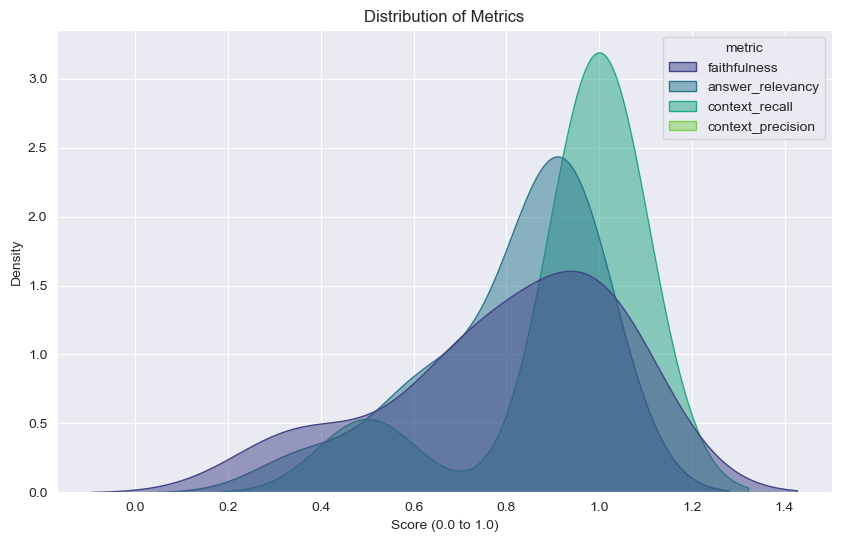

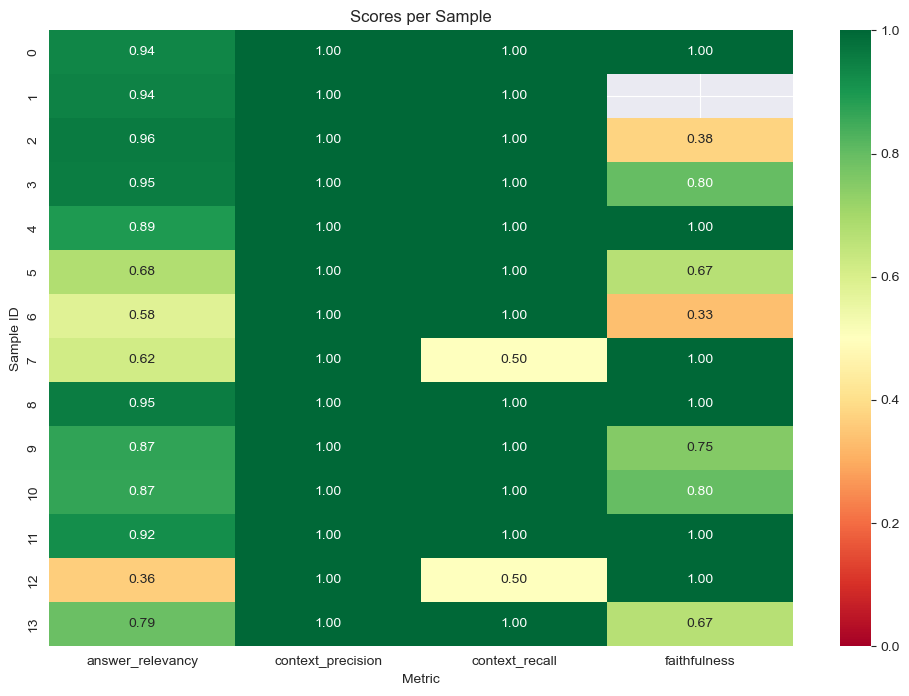

/var/folders/xw/lw8r4ylj1yd5sk0z8q7dwj3r0000gn/T/ipykernel_11550/2680118369.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_scores, x='Metric', y='Average Score', palette='magma')


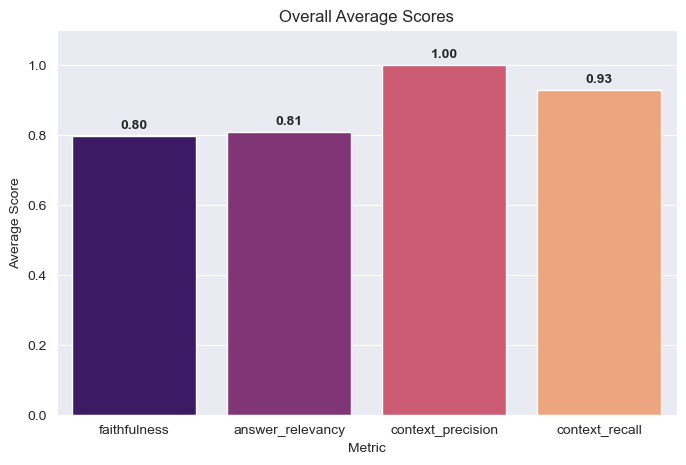

In [ ]:
def main():
    """Run the evaluation pipeline and generate visualizations"""
    dataset = Dataset.from_dict(data_samples)
    eval_scores_df = get_eval_scores(dataset)
    df_metrics, df_melted = prepare_data(eval_scores_df)

    visualize_metric_dist(df_melted)
    visualize_scores_per_sample(df_melted)
    visualize_avg_scores(df_metrics)

if __name__ == "__main__":
    main()